In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from transformers import TimesFmModelForPrediction

TARGET_COLUMN = 'load_kw'
TIMESTAMP_COLUMN = 'timestamp'
DATA_PATH = Path('train_full_final.csv')
MODEL_ID = 'google/timesfm-2.0-500m-pytorch'
VALIDATION_PERIODS = [(2025, 12)]
TEST_PERIODS = [(2025, 4), (2025, 9)]
TIMESFM_FREQ_CODE = 0
CONTEXT_LENGTH = 512
RUN_VALIDATION_CHECK = True
VALIDATION_STRIDE = 4
TRUNCATE_NEGATIVE = True
RESULTS_PATH = Path('timesfm_forecast_results.csv')
METRICS_PATH = Path('timesfm_metrics_summary.csv')
PLOTS_DIR = Path('timesfm_plots')

REQUIRED_COLUMNS = [
    'timestamp', 'p_battery_kw', 'grid_kw', 'pv_kw', 'sell_price', 'buy_price',
    'temperature_c', 'humidity_pct', 'precipitation_mm', 'cloud_cover_pct',
    'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'pressure_hpa',
    'wind_speed_10m', 'wind_speed_100m', 'hour', 'minute', 'day_of_week',
    'day_of_month', 'month', 'quarter', 'week_of_year', 'day_of_year',
    'is_weekend', 'slot_of_day', 'sin_slot', 'cos_slot', 'sin_dow', 'cos_dow',
    'sin_doy', 'cos_doy', 'is_holiday', 'is_low_demand_day', 'load_lag_1',
    'load_lag_4', 'load_lag_8', 'load_lag_96', 'load_lag_192', 'load_lag_672',
    'pv_lag_96', 'buy_price_lag_96', 'sell_price_lag_96', 'sell_price_lag_672',
    'load_roll_mean_4', 'load_roll_mean_96', 'load_roll_std_96', 'load_roll_max_96',
    'load_roll_min_96', 'pv_roll_mean_4', 'sell_price_roll_mean_96',
    'sell_price_roll_std_96', 'temp_squared', 'temp_roll_mean_672',
    'temp_deviation', 'load_kw'
]

In [2]:
def load_data(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f'Could not find {csv_path}. Upload the engineered dataset to Colab.')
    df = pd.read_csv(csv_path)
    missing_columns = sorted(set(REQUIRED_COLUMNS).difference(df.columns))
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')
    df[TIMESTAMP_COLUMN] = pd.to_datetime(df[TIMESTAMP_COLUMN], errors='coerce')
    if df[TIMESTAMP_COLUMN].isna().any():
        raise ValueError('Dataset contains invalid timestamps.')
    df = df.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)
    return df

def format_periods(periods: list[tuple[int, int]]) -> str:
    return ', '.join(f'{year}-{month:02d}' for year, month in periods)

def build_period_mask(df: pd.DataFrame, periods: list[tuple[int, int]]) -> pd.Series:
    timestamps = df[TIMESTAMP_COLUMN]
    years = timestamps.dt.year
    months = timestamps.dt.month
    mask = pd.Series(False, index=df.index)
    for year, month in periods:
        mask |= (years == year) & (months == month)
    return mask

def calculate_metrics(y_true, y_pred) -> dict[str, float]:
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)
    mae = float(mean_absolute_error(y_true_array, y_pred_array))
    rmse = float(np.sqrt(mean_squared_error(y_true_array, y_pred_array)))
    mean_load = float(np.mean(y_true_array))
    nrmse = rmse / mean_load if mean_load != 0 else np.nan
    non_zero_mask = y_true_array != 0
    if np.any(non_zero_mask):
        mape = float(np.mean(np.abs((y_true_array[non_zero_mask] - y_pred_array[non_zero_mask]) / y_true_array[non_zero_mask])) * 100)
    else:
        mape = np.nan
    return {'MAE': mae, 'RMSE': rmse, 'NRMSE': nrmse, 'MAPE_pct': mape}

def plot_actual_vs_predicted(results: pd.DataFrame, output_path: Path) -> None:
    plt.figure(figsize=(16, 6))
    plt.plot(results[TIMESTAMP_COLUMN], results['actual_load_kw'], label='Actual load', linewidth=1.4)
    plt.plot(results[TIMESTAMP_COLUMN], results['predicted_load_kw'], label='Predicted load', linewidth=1.2, alpha=0.9)
    plt.title('TimesFM Residential Load Forecast: Actual vs Predicted')
    plt.xlabel('Timestamp')
    plt.ylabel('Load (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    plt.close()

def plot_residuals(results: pd.DataFrame, output_path: Path) -> None:
    residuals = results['residual_kw']
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    axes[0].plot(results[TIMESTAMP_COLUMN], residuals, linewidth=1.0)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('TimesFM Residuals Over Time')
    axes[0].set_xlabel('Timestamp')
    axes[0].set_ylabel('Actual - Predicted (kW)')
    axes[0].grid(True, alpha=0.3)
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.75)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Residual (kW)')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    plt.close()

def rolling_timesfm_forecast(model, df: pd.DataFrame, target_mask: pd.Series, context_length: int, stride: int = 1) -> pd.DataFrame:
    device = next(model.parameters()).device
    target_indices = np.flatnonzero(target_mask.to_numpy())
    forecast_rows = []
    for position, idx in enumerate(target_indices[::stride], start=1):
        context_start = max(0, idx - context_length)
        context_values = df[TARGET_COLUMN].iloc[context_start:idx].to_numpy(dtype=np.float32)
        if len(context_values) < 32:
            continue
        past_values = [torch.tensor(context_values, dtype=torch.float32, device=device)]
        freq = torch.tensor([TIMESFM_FREQ_CODE], dtype=torch.long, device=device)
        with torch.no_grad():
            outputs = model(
                past_values=past_values,
                freq=freq,
                forecast_context_len=min(context_length, len(context_values)),
                truncate_negative=False,
                return_dict=True,
            )
            prediction = float(outputs.mean_predictions[0, 0].detach().cpu().numpy())
            if TRUNCATE_NEGATIVE:
                prediction = max(prediction, 0.0)
        forecast_rows.append({
            'row_index': int(idx),
            TIMESTAMP_COLUMN: df.at[idx, TIMESTAMP_COLUMN],
            'actual_load_kw': float(df.at[idx, TARGET_COLUMN]),
            'predicted_load_kw': prediction,
            'context_length_used': int(min(context_length, len(context_values))),
        })
        if position % 500 == 0:
            print(f'Processed {position:,} forecasts...')
    results = pd.DataFrame(forecast_rows)
    if results.empty:
        raise ValueError('No forecasts were generated. Check context length and split masks.')
    results['residual_kw'] = results['actual_load_kw'] - results['predicted_load_kw']
    return results


In [3]:
df = load_data(DATA_PATH)
validation_mask = build_period_mask(df, VALIDATION_PERIODS)
test_mask = build_period_mask(df, TEST_PERIODS)
train_pool_mask = ~test_mask

print('Dataset summary')
print(f'Rows: {len(df):,}')
print(f'Date range: {df[TIMESTAMP_COLUMN].min()} -> {df[TIMESTAMP_COLUMN].max()}')
print(f'Validation periods: {format_periods(VALIDATION_PERIODS)}')
print(f'Test periods: {format_periods(TEST_PERIODS)}')
print(f'Non-test pool rows: {int(train_pool_mask.sum()):,}')
print(f'Validation rows: {int(validation_mask.sum()):,}')
print(f'Test rows: {int(test_mask.sum()):,}')

if not validation_mask.any():
    raise ValueError('Validation periods were not found in the dataset.')
if not test_mask.any():
    raise ValueError('Test periods were not found in the dataset.')

Dataset summary
Rows: 69,409
Date range: 2024-01-08 00:00:00 -> 2025-12-31 00:00:00
Validation periods: 2025-12
Test periods: 2025-04, 2025-09
Non-test pool rows: 63,649
Validation rows: 2,881
Test rows: 5,760


In [4]:
model = TimesFmModelForPrediction.from_pretrained(
    MODEL_ID,
    attn_implementation='sdpa',
    device_map='auto',
)
model.eval()
device = next(model.parameters()).device
print(f'Model loaded on device: {device}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/813 [00:00<?, ?it/s]

Model loaded on device: cuda:0


In [5]:
validation_results = None
validation_metrics = None

if RUN_VALIDATION_CHECK:
    validation_results = rolling_timesfm_forecast(
        model=model,
        df=df,
        target_mask=validation_mask,
        context_length=CONTEXT_LENGTH,
        stride=VALIDATION_STRIDE,
    )
    validation_metrics = calculate_metrics(
        validation_results['actual_load_kw'],
        validation_results['predicted_load_kw'],
    )
    print('Validation metrics:')
    for metric_name, metric_value in validation_metrics.items():
        if metric_name == 'MAPE_pct':
            print(f'  {metric_name}: {metric_value:.4f}%')
        else:
            print(f'  {metric_name}: {metric_value:.6f}')


/usr/local/lib/python3.12/dist-packages/transformers/models/timesfm/modeling_timesfm.py:642: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(freq[: len(inputs)], dtype=torch.int32).reshape(-1, 1),


Processed 500 forecasts...
Validation metrics:
  MAE: 0.597587
  RMSE: 0.823412
  NRMSE: 0.395945
  MAPE_pct: 63.7094%


In [6]:
def monthly_metrics(results: pd.DataFrame) -> pd.DataFrame:
    monthly_rows = []
    working = results.copy()
    working[TIMESTAMP_COLUMN] = pd.to_datetime(working[TIMESTAMP_COLUMN])
    working['year_month'] = working[TIMESTAMP_COLUMN].dt.to_period('M').astype(str)
    for year_month, group in working.groupby('year_month', sort=True):
        metrics = calculate_metrics(group['actual_load_kw'], group['predicted_load_kw'])
        monthly_rows.append({
            'year_month': year_month,
            'rows': int(len(group)),
            **metrics,
        })
    monthly_df = pd.DataFrame(monthly_rows)
    return monthly_df.sort_values('year_month').reset_index(drop=True)


/usr/local/lib/python3.12/dist-packages/transformers/models/timesfm/modeling_timesfm.py:642: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(freq[: len(inputs)], dtype=torch.int32).reshape(-1, 1),


Processed 500 forecasts...
Processed 1,000 forecasts...
Processed 1,500 forecasts...
Processed 2,000 forecasts...
Processed 2,500 forecasts...
Processed 3,000 forecasts...
Processed 3,500 forecasts...
Processed 4,000 forecasts...
Processed 4,500 forecasts...
Processed 5,000 forecasts...
Processed 5,500 forecasts...
Per-month test metrics:


,year_month,rows,MAE,RMSE,NRMSE,MAPE_pct
0,2025-04,2880,0.359059,0.613494,0.638994,55.376379
1,2025-09,2880,0.347565,0.594604,0.709349,54.216483



Overall pooled test metrics:
MAE:   0.353312 kW
RMSE:  0.604123 kW
NRMSE: 0.671870
MAPE:  54.7964%

Saved forecasts to: timesfm_forecast_results.csv
Saved metrics to:   timesfm_metrics_summary.csv


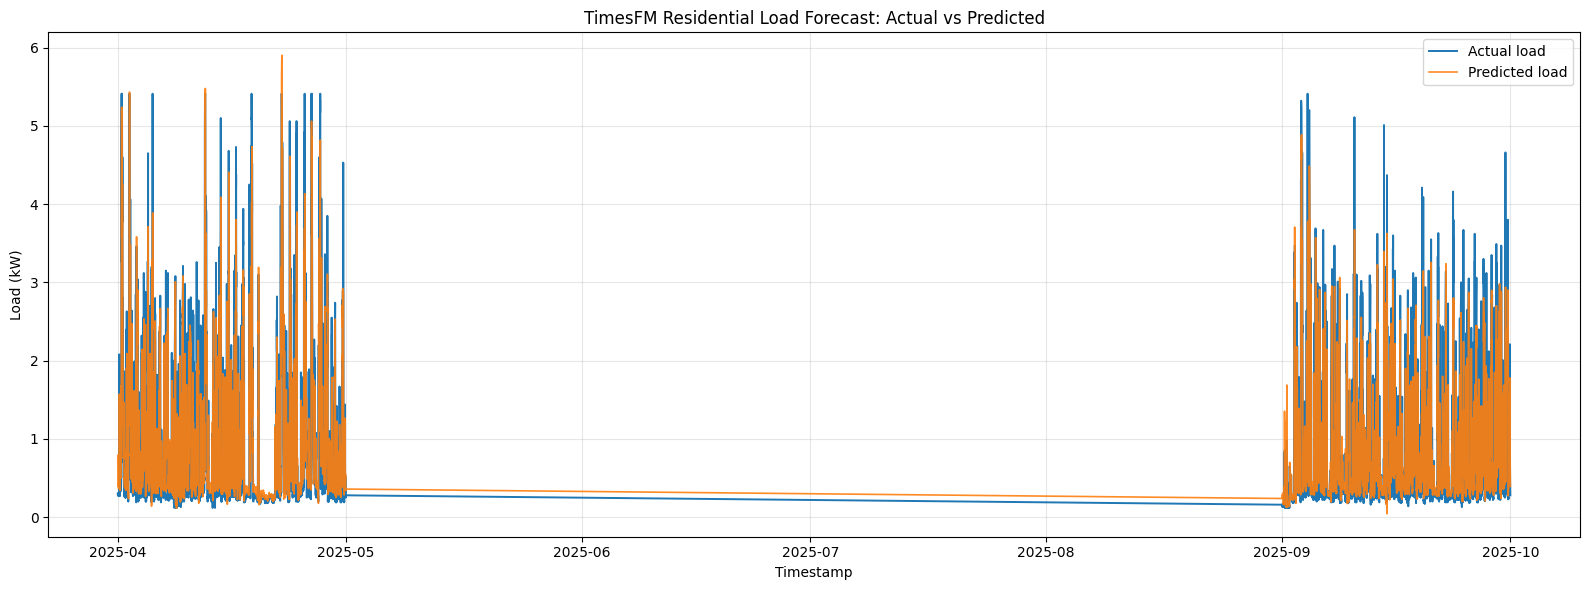

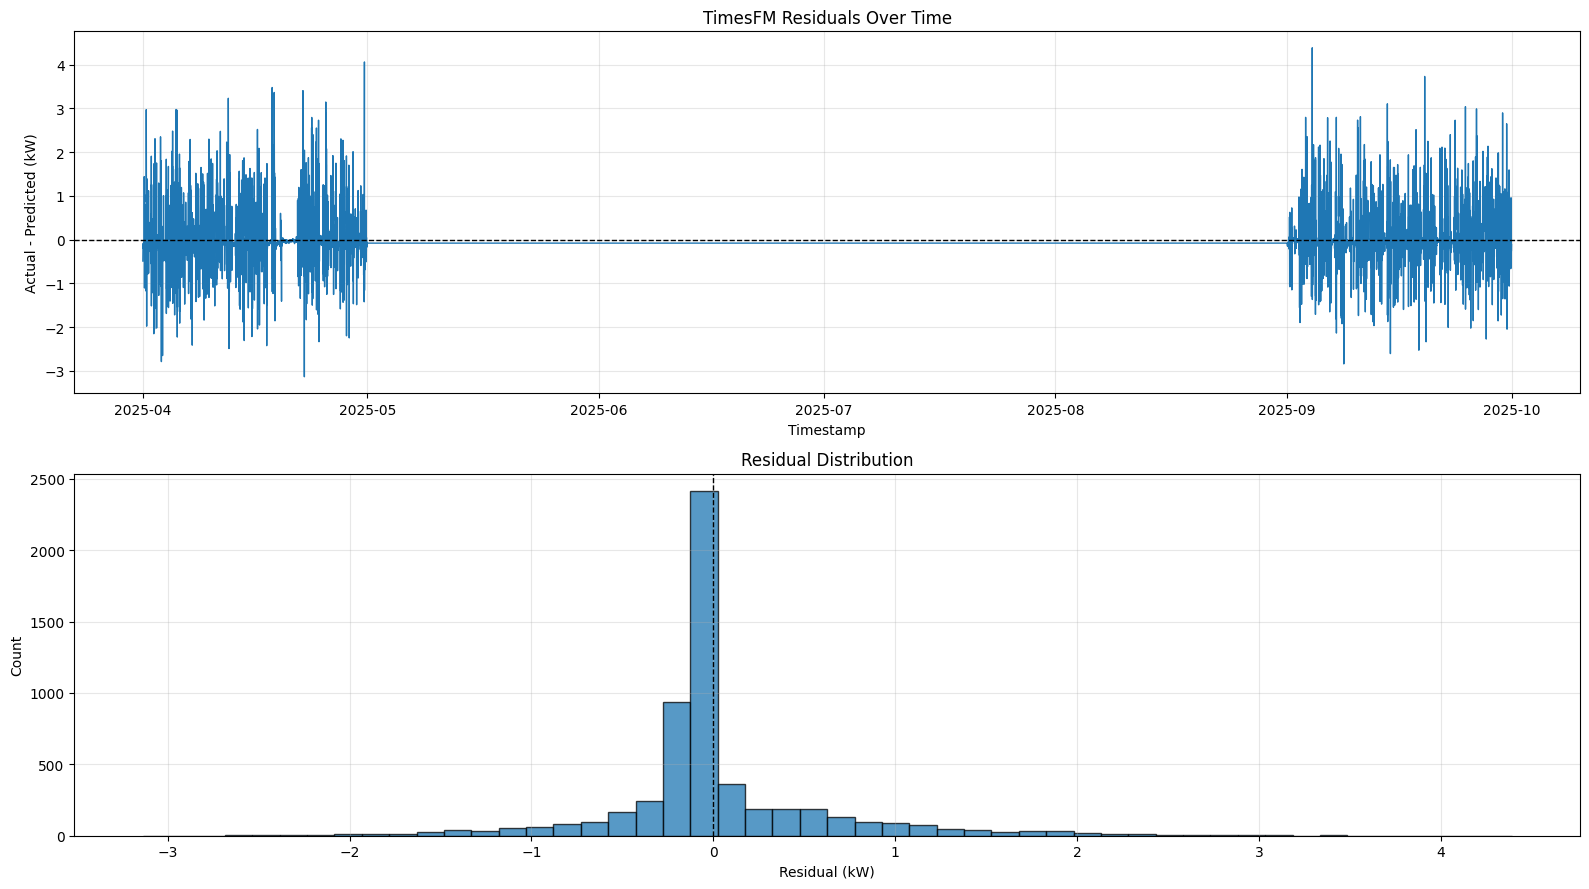

,row_index,timestamp,actual_load_kw,predicted_load_kw,context_length_used,residual_kw
0,43104,2025-04-01 00:00:00,0.30,0.790299,512,-0.490299
1,43105,2025-04-01 00:15:00,0.28,0.501155,512,-0.221155
2,43106,2025-04-01 00:30:00,0.30,0.472214,512,-0.172214
3,43107,2025-04-01 00:45:00,0.30,0.496501,512,-0.196501
4,43108,2025-04-01 01:00:00,0.31,0.430659,512,-0.120659


In [7]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

test_results = rolling_timesfm_forecast(
    model=model,
    df=df,
    target_mask=test_mask,
    context_length=CONTEXT_LENGTH,
    stride=1,
)
test_metrics = calculate_metrics(
    test_results['actual_load_kw'],
    test_results['predicted_load_kw'],
)

test_results.to_csv(RESULTS_PATH, index=False)
monthly_test_metrics = monthly_metrics(test_results)
overall_row = pd.DataFrame([{'year_month': 'ALL_TEST_MONTHS', 'rows': int(len(test_results)), **test_metrics}])
metrics_output = pd.concat([monthly_test_metrics, overall_row], ignore_index=True)
metrics_output.to_csv(METRICS_PATH, index=False)

print('Per-month test metrics:')
display(monthly_test_metrics)
print('\nOverall pooled test metrics:')
print(f"MAE:   {test_metrics['MAE']:.6f} kW")
print(f"RMSE:  {test_metrics['RMSE']:.6f} kW")
print(f"NRMSE: {test_metrics['NRMSE']:.6f}")
print(f"MAPE:  {test_metrics['MAPE_pct']:.4f}%")
print(f'\nSaved forecasts to: {RESULTS_PATH}')
print(f'Saved metrics to:   {METRICS_PATH}')

plot_actual_vs_predicted(test_results, PLOTS_DIR / 'timesfm_actual_vs_predicted.png')
plot_residuals(test_results, PLOTS_DIR / 'timesfm_residuals.png')
display(test_results.head())

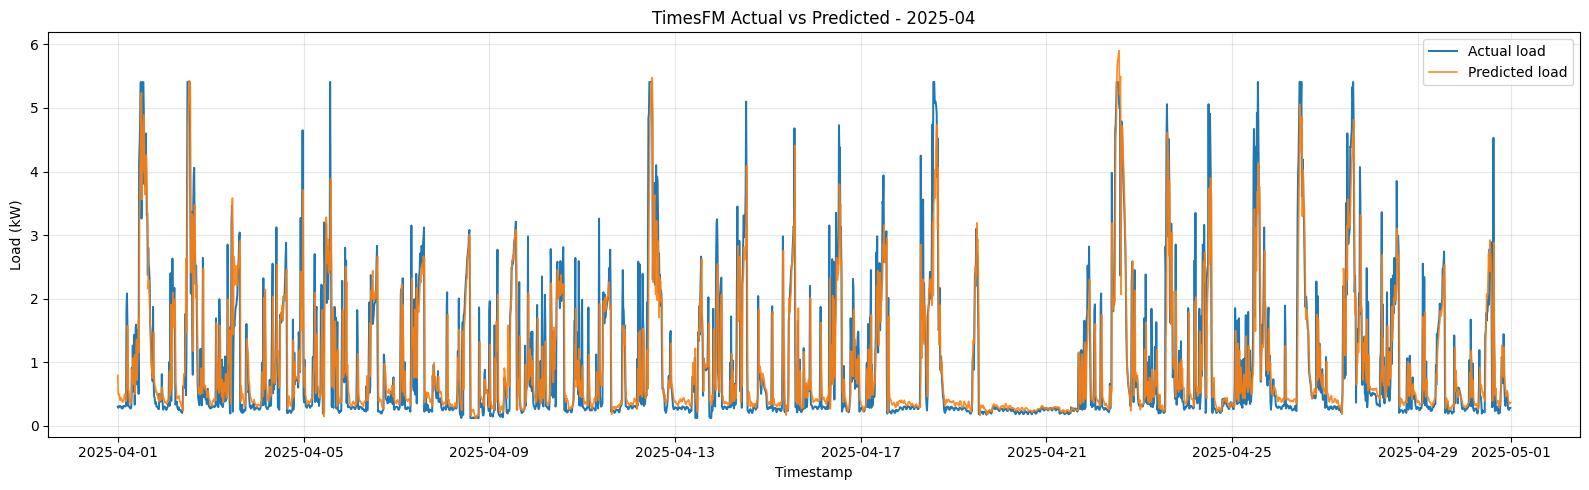

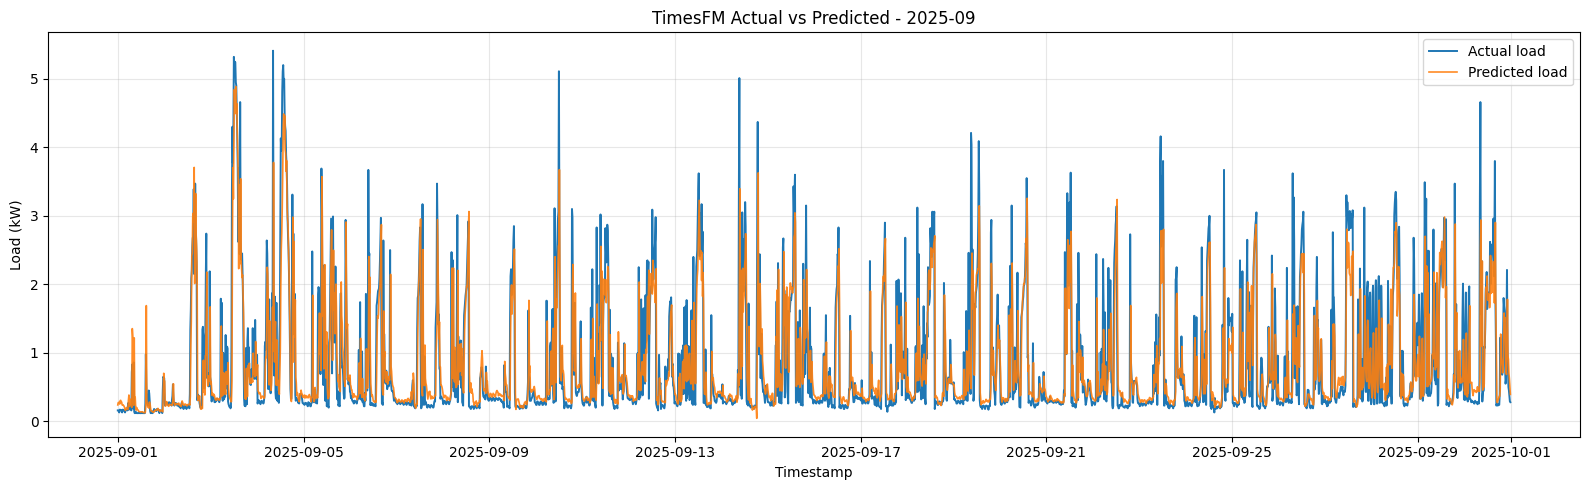

In [8]:
test_results_monthly = test_results.copy()
test_results_monthly[TIMESTAMP_COLUMN] = pd.to_datetime(test_results_monthly[TIMESTAMP_COLUMN])
test_results_monthly['year_month'] = test_results_monthly[TIMESTAMP_COLUMN].dt.to_period('M').astype(str)

for year_month, month_df in test_results_monthly.groupby('year_month', sort=True):
    plt.figure(figsize=(16, 5))
    plt.plot(month_df[TIMESTAMP_COLUMN], month_df['actual_load_kw'], label='Actual load', linewidth=1.4)
    plt.plot(month_df[TIMESTAMP_COLUMN], month_df['predicted_load_kw'], label='Predicted load', linewidth=1.2, alpha=0.9)
    plt.title(f'TimesFM Actual vs Predicted - {year_month}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'timesfm_actual_vs_predicted_{year_month}.png', dpi=160)
    plt.show()
    plt.close()


Outlier diagnostics for 2025-04


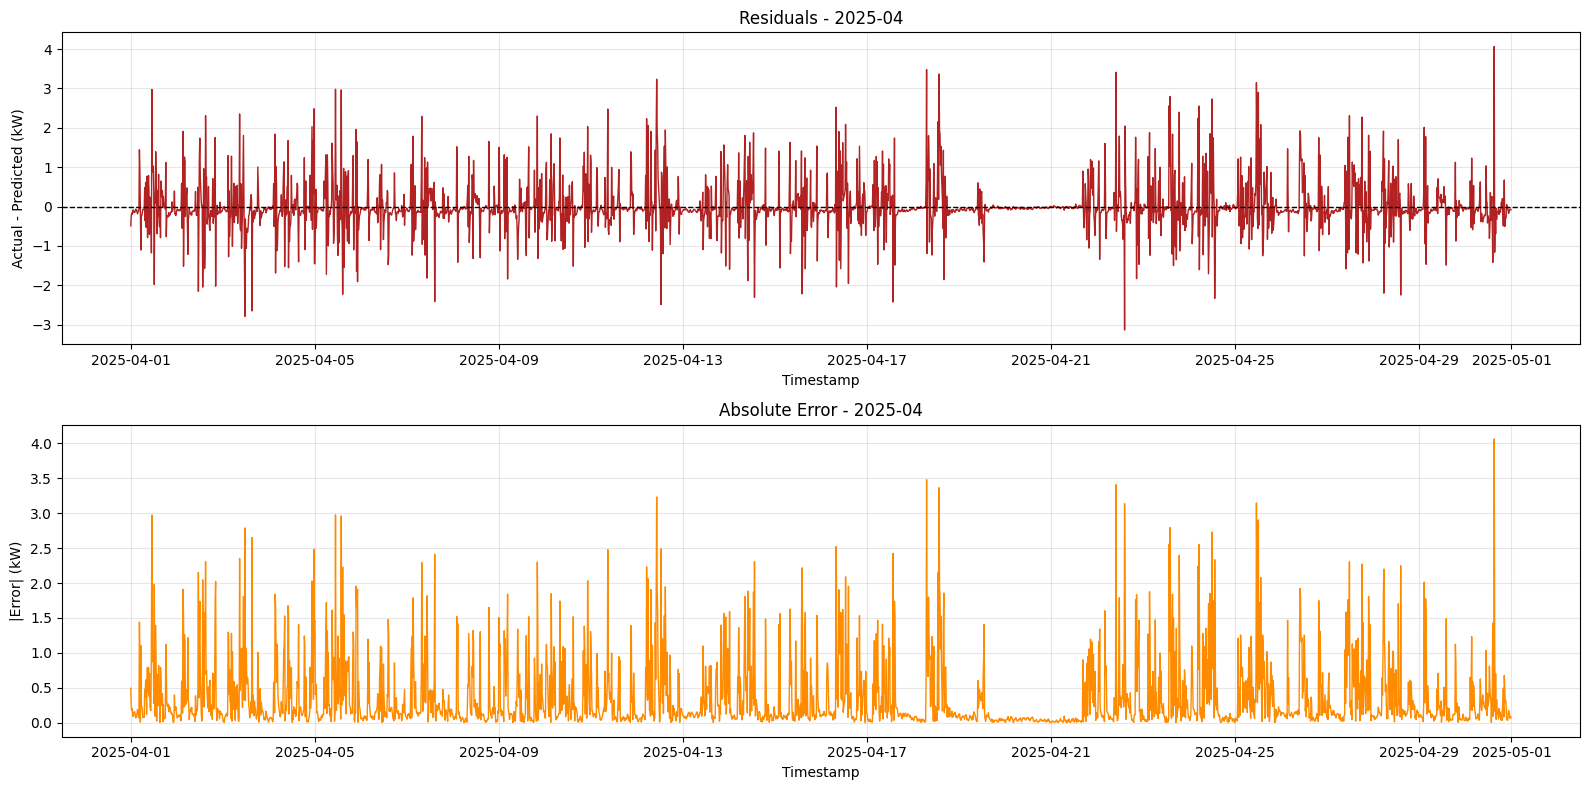

,timestamp,actual_load_kw,predicted_load_kw,residual_kw,abs_error_kw,ape_pct
2844,2025-04-30 15:00:00,4.53,0.465789,4.064211,4.064211,89.717683
1660,2025-04-18 07:00:00,4.25,0.770280,3.479720,3.479720,81.875776
2055,2025-04-22 09:45:00,3.98,0.571324,3.408676,3.408676,85.645117
1686,2025-04-18 13:30:00,5.41,2.043637,3.366363,3.366363,62.224819
1097,2025-04-12 10:15:00,4.84,1.606583,3.233417,3.233417,66.806129
2348,2025-04-25 11:00:00,4.16,1.011950,3.148050,3.148050,75.674273
2073,2025-04-22 14:15:00,2.36,5.496836,-3.136836,3.136836,132.916788
427,2025-04-05 10:45:00,3.20,0.223308,2.976692,2.976692,93.021622
44,2025-04-01 11:00:00,4.13,1.156183,2.973817,2.973817,72.005248
439,2025-04-05 13:45:00,5.41,2.448263,2.961737,2.961737,54.745602


Outlier diagnostics for 2025-09


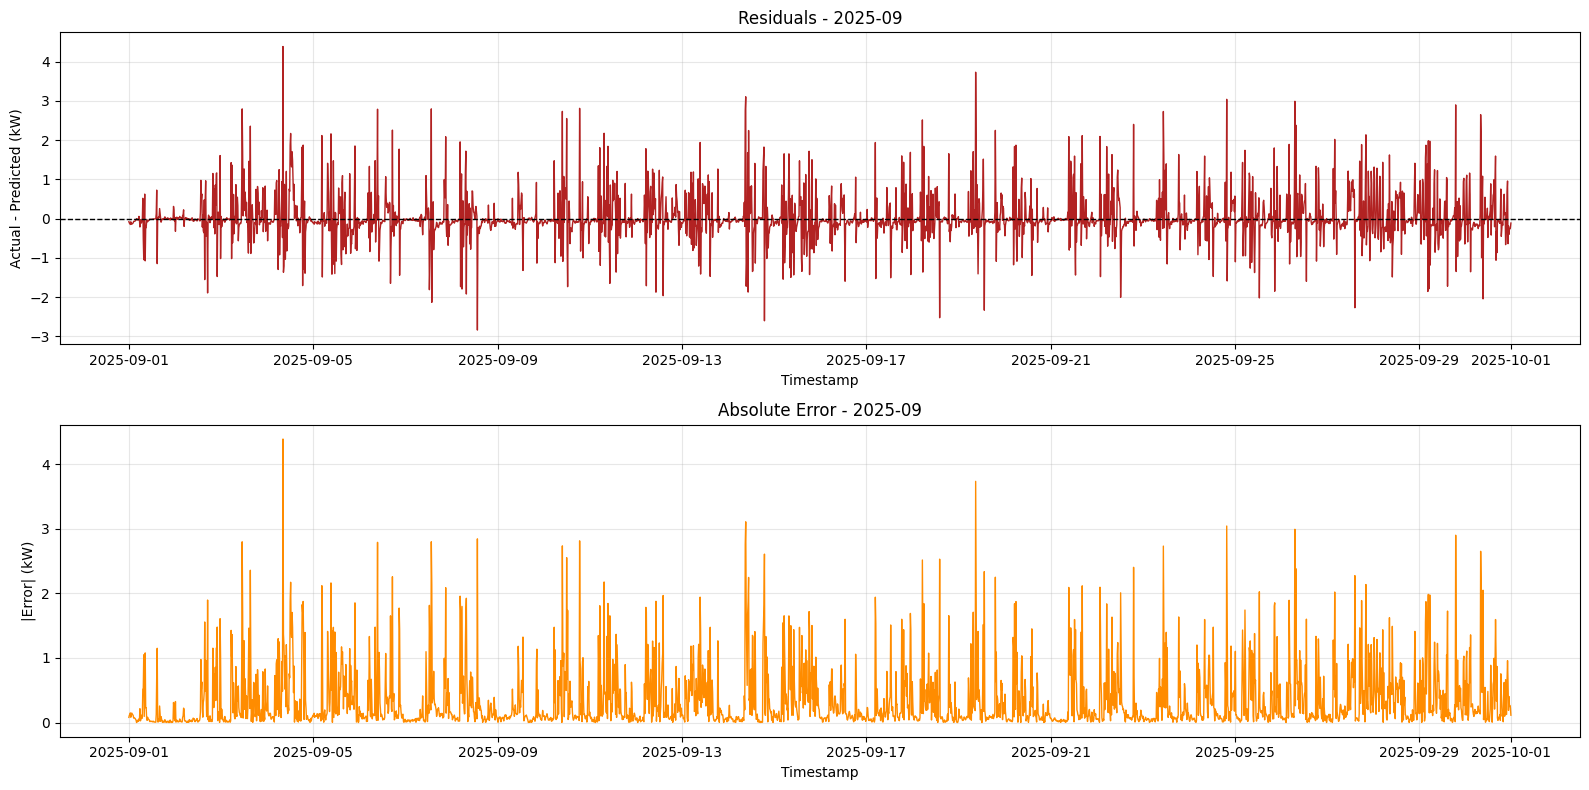

,timestamp,actual_load_kw,predicted_load_kw,residual_kw,abs_error_kw,ape_pct
3201,2025-09-04 08:15:00,5.41,1.021514,4.388486,4.388486,81.118033
4644,2025-09-19 09:00:00,4.21,0.477066,3.732934,3.732934,88.668262
4165,2025-09-14 09:15:00,5.01,1.903190,3.106810,3.106810,62.012173
5167,2025-09-24 19:45:00,3.67,0.628275,3.041725,3.041725,82.880792
5309,2025-09-26 07:15:00,3.62,0.628984,2.991016,2.991016,82.624747
5644,2025-09-29 19:00:00,3.47,0.570736,2.899264,2.899264,83.552272
3606,2025-09-08 13:30:00,0.22,3.062634,-2.842634,2.842634,1292.106251
3819,2025-09-10 18:45:00,3.10,0.288088,2.811912,2.811912,90.706830
3510,2025-09-07 13:30:00,3.17,0.372338,2.797662,2.797662,88.254310
3116,2025-09-03 11:00:00,3.39,0.592787,2.797213,2.797213,82.513668


In [9]:
OUTLIER_TOP_N = 10

test_diagnostics = test_results.copy()
test_diagnostics[TIMESTAMP_COLUMN] = pd.to_datetime(test_diagnostics[TIMESTAMP_COLUMN])
test_diagnostics['year_month'] = test_diagnostics[TIMESTAMP_COLUMN].dt.to_period('M').astype(str)
test_diagnostics['abs_error_kw'] = (test_diagnostics['actual_load_kw'] - test_diagnostics['predicted_load_kw']).abs()
test_diagnostics['ape_pct'] = np.where(
    test_diagnostics['actual_load_kw'] != 0,
    test_diagnostics['abs_error_kw'] / test_diagnostics['actual_load_kw'].abs() * 100,
    np.nan,
)

for year_month, month_df in test_diagnostics.groupby('year_month', sort=True):
    print('=' * 80)
    print(f'Outlier diagnostics for {year_month}')
    print('=' * 80)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].plot(month_df[TIMESTAMP_COLUMN], month_df['residual_kw'], color='firebrick', linewidth=1.0)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title(f'Residuals - {year_month}')
    axes[0].set_xlabel('Timestamp')
    axes[0].set_ylabel('Actual - Predicted (kW)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(month_df[TIMESTAMP_COLUMN], month_df['abs_error_kw'], color='darkorange', linewidth=1.0)
    axes[1].set_title(f'Absolute Error - {year_month}')
    axes[1].set_xlabel('Timestamp')
    axes[1].set_ylabel('|Error| (kW)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'timesfm_outlier_diagnostics_{year_month}.png', dpi=160)
    plt.show()
    plt.close()

    top_outliers = month_df.sort_values('abs_error_kw', ascending=False).head(OUTLIER_TOP_N)[[
        TIMESTAMP_COLUMN,
        'actual_load_kw',
        'predicted_load_kw',
        'residual_kw',
        'abs_error_kw',
        'ape_pct',
    ]]
    display(top_outliers)
